## Intermediate Machine Learning: Assignment 2

**Deadline**

Assignment 2 is due Thursday, October 15 by 11:59 pm. Late work will not be accepted as per the course policies (see the syllabus on Canvas).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. All problems will be given full credit if a significant attempt is made at a solution, whether or not the solution is complete or fully correct. This policy is intended to allow students the freedom to get the most learning value out of the assignment, and to lower incentives to use AI. According to course policy any use of an AI system such as ChatGPT, Claude, or Copilot must be acknowledged.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on Canvas. You can also post questions or start discussions on Ed Discussion. The assignment may look long at first glance, but the problems are broken up into steps that should help you to make steady progress.

**Submission**

Submit your assignment as a .pdf on Gradescope. You can access Gradescope through Canvas on the left-side of the class home page. The problems in each homework assignment are numbered. Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to more easily find your complete solution to each problem.

To produce the .pdf, please do the following in order to preserve the cell structure of the notebook:

1. Go to "File" at the top-left of your Jupyter Notebook.
2. Under "Download as", select "HTML (.html)".
3. After the .html has downloaded, open it and then select "File" and "Print" (note you will not actually be printing).
4. From the print window, select the option to save as a pdf.

If you are working in Colab, you may find it helpful to use this [converter notebook](https://colab.research.google.com/github/YData123/sds365-fa26/blob/main/assignments/Convert_ipynb_to_HTML_in_Colab.ipynb).

**Topics**

 * Backpropagation
 * Gaussian process regression
 * Double descent

This assignment will also help to solidify your Python and Jupyter notebook skills.

## Problem 1: Backpropagation (30 points)

In this problem you will extend the backpropagation formulas from the notes, use them to predict how a small network in the TensorFlow Playground behaves when all of its weights and biases start at zero, prove why part of what you see has to happen, and finally implement backpropagation for this network in Python.

Throughout, "the notes" refers to *Notes on backpropagation* in the "Week 4" row under the "Readings & Notes" column on [our course website](https://ydata123.org/fa26/interml/calendar.html). As in the notes, $P \star Q$ denotes the componentwise product.

Problems 1.2 and 1.3(a) ask you to predict what will happen before you run anything. Predictions (and in fact all parts of this homework) are graded on effort, not correctness—so feel free to make your own predictions, even if they conflict with your later results.

**Screenshots.** To add a screenshot to a markdown cell in Colab, copy the image and paste it into the cell, or drag and drop the image file into the cell.

### 1.1 Extending the notes

The notes derive backpropagation for a two-layer network. Here you will extend these results to a network with an **arbitrary activation function** $\varphi$ in the hidden layer and a **tanh at the output**. This is the network that the TensorFlow Playground uses in 1.2 and 1.3.

For an input $x \in \mathbb{R}^d$ with label $y \in \{-1, +1\}$, the network computes
$$
h = \varphi(W_1 x + b_1), \quad f = \tanh(W_2 h + b_2), \quad {L} = \tfrac{1}{2}(y - f)^2,
$$
where $W_1 \in \mathbb{R}^{m \times d}$, $b_1 \in \mathbb{R}^m$, $W_2 \in \mathbb{R}^{1 \times m}$ and $b_2 \in \mathbb{R}$. The activation $\varphi$ is any differentiable function, applied componentwise, with derivative $\varphi'$. The network has $m$ hidden neurons.

**(a)** Let $s=W_2h+b_2$, so that $f=\tanh(s)$. Show that
$$
\delta := \frac{\partial {L}}{\partial s} = (f - y)(1 - f^2).
$$
Here $\tanh(u) = \frac{\sinh(u)}{\cosh(u)} = \frac{e^u - e^{-u}}{e^u + e^{-u}}$, and you may use $\tanh'(u) = 1 - \tanh^2(u)$.

**(b)** Using the $\delta$ you just obtained, show that
$$
\begin{aligned}
\frac{\partial {L}}{\partial W_2} &= \delta\, h^\top, \\
\frac{\partial {L}}{\partial b_1} &= \varphi'(W_1 x + b_1) \star (\delta W_2^\top), \\
\frac{\partial {L}}{\partial W_1} &= \left( \varphi'(W_1 x + b_1)\star (\delta W_2^\top) \right) x^\top.
\end{aligned}
$$

**(a)**
We have
$$L = \frac{1}{2}(y - f)^2$$
By the chain rule,
$$\frac{\partial L}{\partial s} = \frac{1}{2} \frac{\partial}{\partial f} (y - f)^2 \frac{\partial f}{\partial s}$$
Here, as defined, $f = \text{tanh}(s)$. Thus
$$\frac{\partial L}{\partial s} = (f - y)(1 - \text{tanh}^2(s))$$
$$\implies \frac{\partial L}{\partial s} = (f - y)(1 - f^2)$$
$$\implies \delta = (f - y)(1 - f^2)$$

**(b)**
We have $s = W_2 h + b_2$ and $h = \varphi(W_1 x + b_1)$. Thus, we get
$$\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial s} h^T = \delta h^T$$
Similarly, we get
$$\frac{\partial L}{\partial h} = \frac{\partial L}{\partial s} W_2^T = \delta W_2^T$$

Now, using the chain rule, we get
$$\frac{\partial L}{\partial b_1} = \frac{\partial h}{\partial b_1} \times \frac{\partial L}{\partial h}$$
$$\frac{\partial L}{\partial b_1} = \varphi'(W_1 x + b_1) \times \frac{\partial L}{\partial h}$$
$$\implies \frac{\partial L}{\partial b_1} = \varphi'(W_1 x + b_1) \times (\delta W_2^T)$$

Similarly, using the chain rule again, we get
$$\frac{\partial L}{\partial W_1} = \varphi'(W_1x + b_1) \times (\frac{\partial L}{\partial h}) x^T$$
$$\implies \frac{\partial L}{\partial W_2} = (\varphi'(W_1x + b_1) \times (\delta W_2^T)) x^T$$

### The network in the TensorFlow Playground

In 1.2 and 1.3 we use the network of 1.1 in the TensorFlow Playground, which you saw in class, with $d = 2$ inputs (the features $X_1$ and $X_2$) and $m = 3$ hidden neurons. The data are the "circle" dataset: the blue points inside have label $y = +1$, and the orange points outside have label $y = -1$.

The Playground uses exactly the tanh output and the loss ${L} = \tfrac{1}{2}(y - f)^2$ of 1.1. It averages the gradients over mini-batches of 10 training points and updates every parameter by gradient descent with learning rate $\eta = 0.03$.

**[Open the Playground network](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=3&seed=0.12345&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=true&hideText=true)**

This link sets **every weight and bias to zero**. (Zero initialization is not available in the Playground menus, **only through this link**.)

Tips for using the Playground:
* The ▶ button starts and pauses training. The epoch counter is at the top; the training and test loss, with a small loss curve, are at the top right. 1000 epochs take about 10 seconds.
* Each square in the middle column is a hidden neuron. Its picture shows the neuron's output $h_j$ over the input plane. Hover over a neuron to see it enlarged.
* Blue means positive and orange means negative, for data, neuron outputs and weights. The thickness of a connection shows the size of its weight. Click on a connection to read its value.
* Changing the activation function rebuilds the network with every weight and bias equal to zero.
* You should see three blank hidden neurons with gray connections. If not, try reloading the page.

### 1.2 Dead ReLU

*Predict.* Before running anything, predict what happens when every weight and bias is zero and $\varphi = \mathrm{ReLU}$. You can organize your prediction and observations by answering the following three questions:

1. Will the training loss go down?
2. What will the three hidden neurons look like after about 1000 epochs?
3. What are the values of the weights $W_1$ after about 1000 epochs?

Hint:

- $\mathrm{ReLU}(x) = \max(0, x)$ so we know $\mathrm{ReLU}(0) = 0$

- Mathematically, $\mathrm{ReLU}$ is not differentiable at $x = 0$: its subdifferential there is the interval $[0, 1]$, so any value in $[0, 1]$ is a valid subgradient. In practice, the Playground, like mainstream frameworks such as TensorFlow and PyTorch, uses $\mathrm{ReLU}'(x) = 0$ for $x \le 0$.

You may reason with your formulas from 1.1, but no justification for your predictions is needed.

*Verify.* Open the link above ([TensorFlow Playground](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=3&seed=0.12345&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=true&hideText=true)); train for about 1000 epochs and take a screenshot. Describe what you see. *You do not need a screenshot at exactly 1000 epochs; any nearby epoch is fine.*

*Reflect.* Compare with your prediction. Then explain what you saw using the expressions you obtained in problem 1.1.

*Extend.* The Playground uses $\mathrm{ReLU}'(0) = 0$. Suppose instead that $\mathrm{ReLU}'(0) = c$ for some $c \in (0, 1]$, which is also a valid subgradient. Would the outcome of this experiment change? Justify your answer using the formulas you derived in 1.1. *The Playground does not let you change $\mathrm{ReLU}'(0)$, so answer this by reasoning; no screenshot is needed.*

**Answer to 1.2.**

> **My prediction** (written before running): ...
- I think that as the number of epochs rises, the training loss will go down.
- My assumption is that after 1000 about epochs, the 3 hidden neurons will range from grey to blue (0 to 1) since the non-linearity function is ReLU and $h = \varphi(W_1 x + b_1)$
- I think the values of the weights $W_1$ will mostly be non-zero and $W_1 \in \mathbb{R}$ as the neural network works to minimize the loss function.

> **What I observed** (screenshot(s) and a short description): ...
- Screenshot:
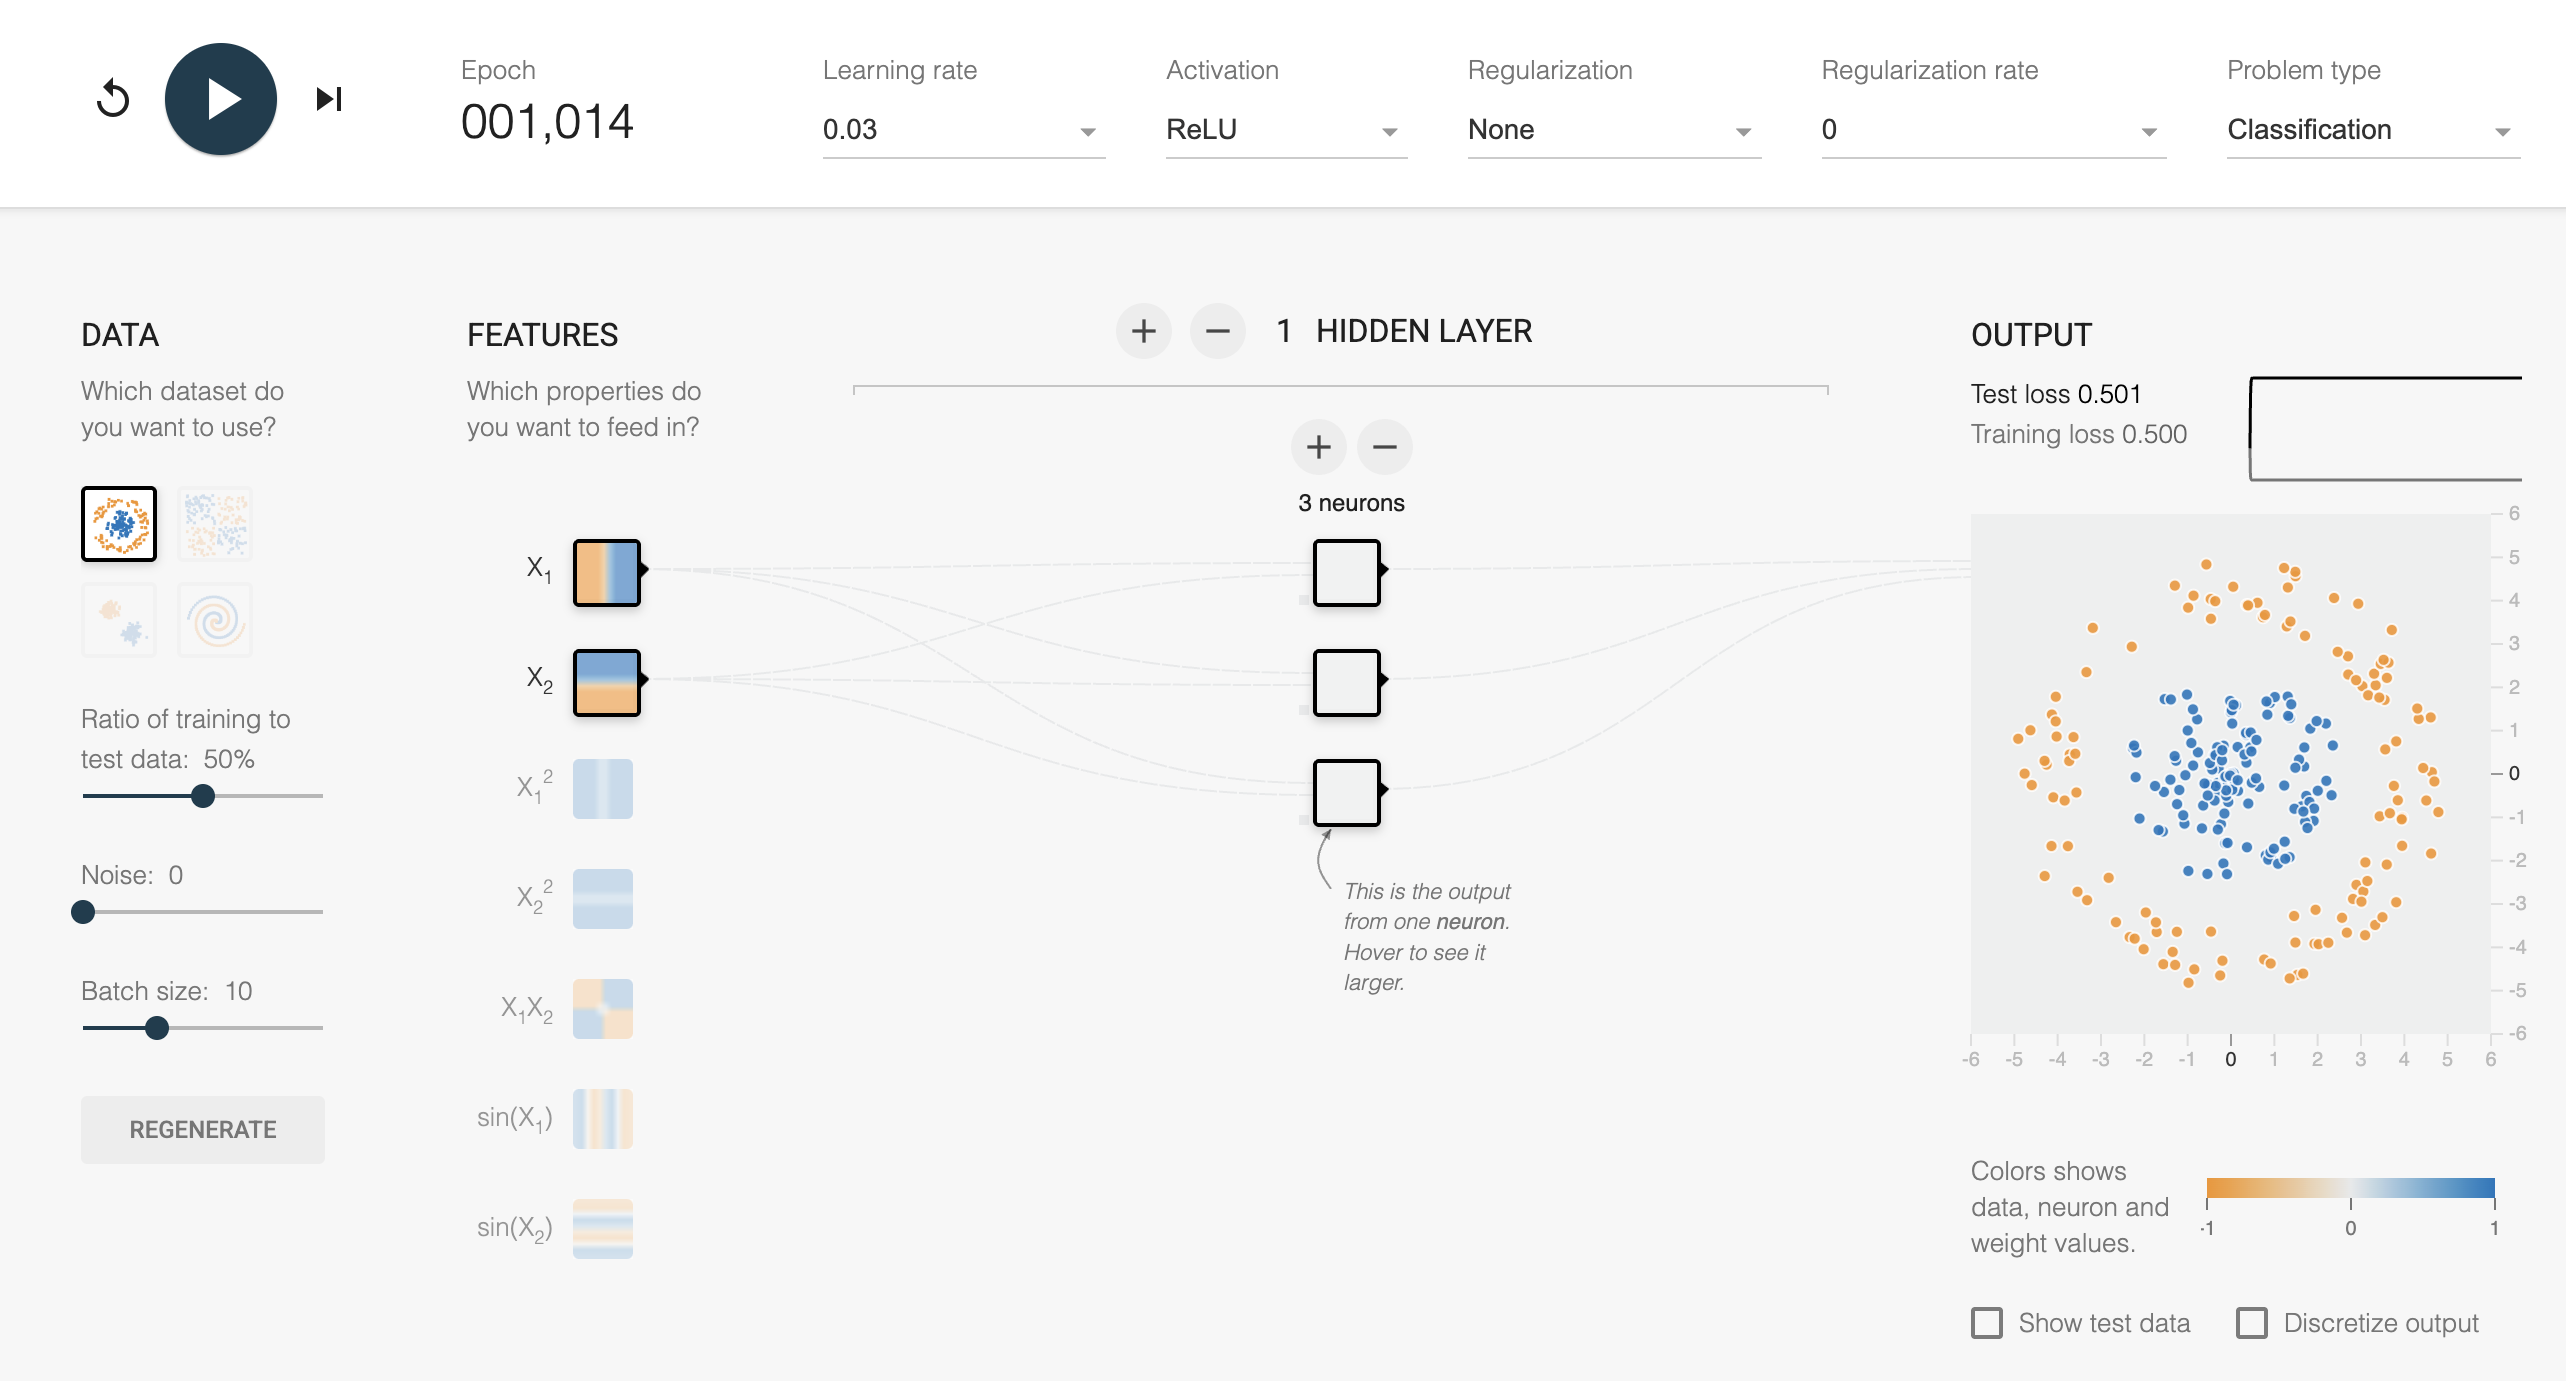

- Description: Here, we notice that even after 1000 epochs, the weights $W_1$ and the values of the 3 hidden neurons are exactly 0. Furthermore, we notice that the training loss does not go down, and in fact, stays at exactly 0.5.

> **Reflection** (at most three sentences; use your results from 1.1): ...
- Based on the descriptions above, I realize that my prediction was completely incorrect.
- Having looked at the results, I realize that since $W_1$ and $b_1$ were initialized at 0, $h = \text{ReLU}(W_1 x + b_1) = 0$. Thus, $f = \text{tanh}(W_2 h + b_2) = \text{tanh}(0) = 0$ for all $x$ since $W_2$ and $b_2$ are also initialized at 0. Thus, our output $\hat{y}$ is always 0, which yields the 0.5 training loss (assuming a 50-50 split of -1's and 1's). Since we have $\text{ReLU}'(0) = 0, \frac{\partial l}{\partial b_1} \propto \text{ReLU}'(0)$ and $\frac{\partial L}{\partial W_1} \propto \text{ReLU}'(0)$ also remain at 0. Thus, the weights and biases remain at 0.

> **If $\mathrm{ReLU}'(0) > 0$** (Yes or No, with a justification using your results from 1.1): ...

### 1.3 Symmetric State

**(a) Sigmoid.** The sigmoid activation function is
$$
\sigma(u) = \frac{1}{1 + e^{-u}}, \qquad \sigma'(u) = \sigma(u)\big(1 - \sigma(u)\big).
$$
In particular, $\sigma(0) = \tfrac{1}{2}$ and $\sigma'(0) = \tfrac{1}{4}$.

We will investigate the same zero initialization as in problem 1.2, but with the sigmoid activation.

*Predict.* With every weight and bias initialized to zero and $\varphi = \sigma$, predict:
1. How does this compare with the outcome in problem 1.2?
2. Will the three hidden neurons end up looking different from each other?
3. What will the weights look like? Compare different components within $W_1$ and $W_2$. You do not need to report specific numerical values.

*Verify.* Open the [Playground network with the sigmoid activation](https://playground.tensorflow.org/#activation=sigmoid&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=3&seed=0.12345&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=true&hideText=true). The Activation is already set to Sigmoid, and every weight and bias is zero. Train for about 1000 epochs and take a screenshot. Describe what you see by addressing the three questions above.

*You do not need a screenshot at exactly 1000 epochs; any nearby epoch is fine. Since a single screenshot may not fully capture Question 3, you may answer it in words and attach just one screenshot.*

We will investigate this phenomenon in part (b).

**Answer to 1.3(a).**

> **My prediction** (written before running): ...

> **What I observed** (screenshot(s) and a short description): ...

**(b) Symmetry preservation**

*Definition (the symmetric state ${S}$).* Consider the Playground network: the network of 1.1 with $d = 2$ inputs and $m = 3$ hidden neurons. Its parameters are in the *symmetric state* ${S}$ if all hidden neurons have identical incoming weights, identical biases and identical outgoing weights:
$$
W_1 = \begin{pmatrix} w_1^\top \\ w_1^\top \\ w_1^\top \end{pmatrix}, \qquad
b_1 = \begin{pmatrix} c_1 \\ c_1 \\ c_1 \end{pmatrix}, \qquad
W_2 = \begin{pmatrix} w_2 & w_2 & w_2 \end{pmatrix},
$$
where $w_1 \in \mathbb{R}^2$ is the common weight vector of the first layer, $c_1 \in \mathbb{R}$ is the common bias and $w_2 \in \mathbb{R}$ is the common weight of the output layer. The output bias $b_2$ can be anything.

*Property.* If the parameters are in the symmetric state ${S}$ at any point during training, then after one gradient descent step on a mini-batch of any size, the parameters are still in ${S}$.

*Task.* Prove the property stated above.

(Note: This property explains why the three hidden neurons end up identical in 1.3(a). You only need to prove the property here; no additional explanation is required.)

[Your answer to 1.3(b) here]

### 1.4 Backpropagation in Python

In this part you will complete a simple Python implementation of the network we used in the TensorFlow Playground. You will write the backward functions for the $\mathrm{ReLU}$ activation and the linear layer.

As in 1.1, all vectors are column vectors: the code handles one training point at a time. There are five code cells:
1. The building blocks we provide.
2. The two backward functions you complete in (a).
3. The network with $\varphi = \mathrm{ReLU}$, trained with mini-batches of 10 points and learning rate $0.03$, as in the Playground (provided).
4. A check of your two functions (provided).
5. The symmetric-state experiment of (b).

The first code cell below contains the blocks we provide. Read `tanh_backward` carefully; it is a complete example of the backward function of an activation. **DO NOT EDIT THE FOLLOWING CELL**

In [ ]:
# Please do not edit this cell.
import numpy as np

# Each building block has a forward function and a backward function.
#   forward(input)               returns the output
#   backward(input, grad_output) returns grad_input
# where grad_output = dL/d(output) and grad_input = dL/d(input).

# ----- The loss: L = 1/2 (y - f)^2 -----
def loss_forward(f, y):
    return 0.5 * (y - f) ** 2

def loss_backward(f, y):
    """Returns dL/df = f - y (equation (4) of the notes)."""
    return f - y

# ----- The tanh activation -----
def tanh_forward(s):
    return np.tanh(s)

def tanh_backward(s, grad_output):
    """s: the input of tanh. grad_output: dL/d(tanh(s)).
    Returns dL/ds = tanh'(s) * grad_output, where tanh'(s) = 1 - tanh(s)^2."""
    return (1 - np.tanh(s) ** 2) * grad_output

# ----- The ReLU activation -----
def relu_forward(z):
    return np.maximum(z, 0)

# ----- A linear layer: out = W x + b -----
def linear_forward(x, W, b):
    return W @ x + b          # @ is the matrix product

**(a)** Complete the two backward functions in this cell.

In [ ]:
def relu_backward(z, grad_output):
    """Backward function of ReLU(z), applied componentwise.
    z: the input of ReLU, shape (m, 1).
    grad_output: dL/dh, shape (m, 1).
    You should return dL/dz, shape (m, 1).
    Use ReLU'(u) = 0 if u = 0."""
    # TODO
    grad_z = None
    return grad_z


def linear_backward(x, W, b, grad_output):
    """Backward function of a linear layer with output = W x + b.
    x: the input, shape (d, 1).
    W: the weights, shape (m, d).
    b: the biases, shape (m, 1).
    grad_output: dL/d(out), shape (m, 1).
    You should return grad_x = dL/dx, shape (d, 1); grad_W = dL/dW, shape (m, d); grad_b = dL/db, shape (m, 1)."""
    # TODO
    grad_x = None
    grad_W = None
    grad_b = None
    return grad_x, grad_W, grad_b

The next cell puts the blocks together into the network with $\varphi = \mathrm{ReLU}$ and trains it with mini-batches of 10 points and learning rate $0.03$. **DO NOT EDIT THE FOLLOWING CELL**

In [ ]:
# Please do not edit this cell.

def forward_backward(x, y, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]

    # Forward pass. We keep every intermediate result, because the backward pass needs them.
    z = linear_forward(x, W1, b1)          # z = W1 x + b1
    h = relu_forward(z)                    # h = ReLU(z)
    s = linear_forward(h, W2, b2)          # s = W2 h + b2
    f = tanh_forward(s)                    # f = tanh(s)
    loss = loss_forward(f, y)              # L = 1/2 (y - f)^2

    # Backward pass.
    grad_f = loss_backward(f, y)                                    # dL/df
    grad_s = tanh_backward(s, grad_f)                               # dL/ds
    grad_h, grad_W2, grad_b2 = linear_backward(h, W2, b2, grad_s)   # dL/dh, dL/dW2, dL/db2
    grad_z = relu_backward(z, grad_h)                               # dL/dz
    grad_x, grad_W1, grad_b1 = linear_backward(x, W1, b1, grad_z)   # dL/dx, dL/dW1, dL/db1

    grads = {"W1": grad_W1, "b1": grad_b1, "W2": grad_W2, "b2": grad_b2}
    return loss.item(), grads


def batch_gradients(X, Y, params):
    """Average loss and gradients across a batch."""
    total_loss = 0.0
    total_grads = {name: np.zeros_like(value) for name, value in params.items()}
    for x, y in zip(X, Y):
        loss, grads = forward_backward(x.reshape(2, 1), y, params)
        total_loss += loss
        for name in params:
            total_grads[name] += grads[name]
    n = len(Y) # n is the batch size.
    return total_loss / n, {name: g / n for name, g in total_grads.items()}


def train(params, X, Y, epochs=200, lr=0.03, batch_size=10):
    """Mini-batch gradient descent."""
    losses = [] # Record the loss history.
    for epoch in range(epochs):
        for start in range(0, len(Y), batch_size):
            _, grads = batch_gradients(X[start:start + batch_size], Y[start:start + batch_size], params)
            for name in params:
                params[name] -= lr * grads[name] # Gradient descent.
        losses.append(batch_gradients(X, Y, params)[0]) # Record the loss after an epoch.
    return losses


def make_circle_data(n=200, seed=0):
    """The Playground's "circle" data: label +1 inside radius 2.5, label -1 in the ring between radius 3.5 and 5."""
    rng = np.random.default_rng(seed)
    radius = np.concatenate([rng.uniform(0, 2.5, n // 2), rng.uniform(3.5, 5, n // 2)])
    angle = rng.uniform(0, 2 * np.pi, n)
    X = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
    Y = np.concatenate([np.ones(n // 2), -np.ones(n // 2)])
    order = rng.permutation(n)
    return X[order], Y[order]


X_circle, Y_circle = make_circle_data()

The next cell checks your two functions by comparing your gradients with numerical (finite-difference) gradients. **DO NOT EDIT THE FOLLOWING CELL**

In [ ]:
# Please do not edit this cell.

def check_gradients(eps=1e-6):
    rng = np.random.default_rng(1)
    params = {"W1": rng.normal(size=(3, 2)), "b1": rng.normal(size=(3, 1)),
              "W2": rng.normal(size=(1, 3)), "b2": rng.normal(size=(1, 1))} # An example network to check your gradients.
    x, y = rng.normal(size=(2, 1)), 1.0 # Some example data to check your gradients.
    try:
        _, grads = forward_backward(x, y, params)
    except TypeError as error:
        print(f"The backward pass failed ({error}).")
        print("Make sure both functions are complete and return arrays, not None.")
        return
    all_ok = True
    for name, value in params.items():
        if grads[name] is None:
            print(f"dL/d{name}: not computed yet (None). Complete the TODOs above.")
            all_ok = False
            continue
        if np.shape(grads[name]) != value.shape:
            print(f"dL/d{name}: shape {np.shape(grads[name])}, but it should be {value.shape}")
            all_ok = False
            continue
        numerical = np.zeros_like(value) # Compute the finite difference approximation so we can compare your gradients with them.
        for idx in np.ndindex(value.shape):
            old = value[idx]
            value[idx] = old + eps
            loss_plus, _ = forward_backward(x, y, params)
            value[idx] = old - eps
            loss_minus, _ = forward_backward(x, y, params)
            value[idx] = old
            numerical[idx] = (loss_plus - loss_minus) / (2 * eps)
        error = np.max(np.abs(grads[name] - numerical))
        print(f"dL/d{name}: largest difference from the numerical gradient = {error:.1e}")
        all_ok = all_ok and error < 5e-6
    print("All gradients are correct!" if all_ok else "Some gradients are wrong. Check your two functions.")

check_gradients()

**(b)** In the next cell, replace every `____` with a number so that the parameters are in the symmetric state ${S}$ of 1.3(b). The cell then trains the network for 200 epochs and checks whether the parameters are still in ${S}$, so you can verify the property you proved in 1.3(b) in code.

In [ ]:
____ = None   # Marks a blank. Do not edit this line.

# TODO: replace every ____ by a number to create a symmetric state, then run this cell.
W1 = [[    ____,     ____   ],   # neuron 1
      [    ____,     ____   ],   # neuron 2
      [    ____,     ____   ]]   # neuron 3

#        neuron 1   neuron 2   neuron 3
b1 = [     ____,      ____,      ____   ]
W2 = [     ____,      ____,      ____   ]

b2 = ____

def make_params(W1, b1, W2, b2):
    """Turn the lists of numbers you type into NumPy arrays with the shapes of 1.1.
    Check if a shape is wrong or if a number is missing."""
    params = {}
    for name, values, shape in [("W1", W1, (3, 2)), ("b1", b1, (3,)), ("W2", W2, (3,)), ("b2", b2, ())]:
        array = np.array(values, dtype=object)
        if array.shape != shape:
            print(f"{name} has shape {array.shape}, but it should have shape {shape}.")
            return None
        if any(v is None or isinstance(v, bool) or not isinstance(v, (int, float)) for v in array.ravel()):
            print(f"{name} still contains a blank ____. Replace every ____ by a number.")
            return None
        params[name] = array.astype(float)
    params["b1"] = params["b1"].reshape(3, 1)
    params["W2"] = params["W2"].reshape(1, 3)
    params["b2"] = params["b2"].reshape(1, 1)
    return params

def in_symmetric_state(params):
    """True if all hidden neurons have identical incoming weights, biases and outgoing weights."""
    W1, b1, W2 = params["W1"], params["b1"], params["W2"]
    return np.allclose(W1, W1[0]) and np.allclose(b1, b1[0]) and np.allclose(W2, W2[0, 0])

params = make_params(W1, b1, W2, b2)

if params is not None and not in_symmetric_state(params):
    print("These parameters are not in the symmetric state. Check W1, b1 and W2.")
elif params is not None:
    # Train for 200 epochs.
    losses = train(params, X_circle, Y_circle, epochs=200)

    # Check whether the parameters are still in the symmetric state.
    print("Still in the symmetric state after training:", in_symmetric_state(params))

**Remark** (nothing to submit). These problems show how a poor initialization can break training through backpropagation. The symmetric state is a simple example that is easy to see; in real applications, bad initializations can also stall training in much more subtle ways. A large body of research in machine learning studies initialization.

## Problem 2: All that glitters (20 points)

In this problem you will use Gaussian process regression to model the trends in gold medal performances of selected events in the summer Olympics. The objectives of this problem are for you to:

* Gain experience with Gaussian processes, to better understand how they work
* Explore how posterior inference depends on the properties of the prior mean and kernel
* Use Bayesian inference to identify unusual events
* Practice making your Python code modular and reusable

For this problem, the only starter code we provide is to read in the data and extract
one event. You may write any GP code that you choose to, but please do not use any
package for Gaussian processes; your code should be "np-complete" (using only
basic `numpy` methods). You are encouraged to start from the [GP demo code](https://ydata123.org/fa26/interml/calendar.html) used in class.


When we ran the GP demo code from class on the marathon data, it generated the following plot:
<img src="https://raw.githubusercontent.com/YData123/sds365-sp22/main/assignments/assn2/marathon.jpg" width="600">

Note several properties of this plot:
* It shows the posterior uncertainty of the regression as a shaded area. This is a 95% credible band because it extends $\pm 2 \sqrt{V}$, where $V$ is the estimated variance. The variance increases at the right side, for future years.

* The gold medal time for the 1904 marathon is outside of this confidence band. In fact, the 1904 marathon was an [unusual event](https://www.smithsonianmag.com/history/the-1904-olympic-marathon-may-have-been-the-strangest-ever-14910747/), and this is apparent from the model.

* The plot shows the posterior mean, and also shows one random sample from the posterior distribution.

Your task in this problem is to generate such a plot for six different Olympic events by writing a function

```python
def gp_olympic_event(year, result, kernel, mean, noise, event_name):
    ...
```

where the input variables are the following:

* `year`: a numpy array of years (integers)
* `result`: a numpy array of numerical results, for the gold medal performances in that event
* `kernel`: a kernel function
* `mean`: a mean function
* `noise`: a single float for the variance of the noise, $\sigma^2$
* `event_name`: a string used to label the y-axis, for example "marathon min/mile (men's event)"

Your function should compute the Gaussian process regression, and then display the resulting plot, analogous to the plot above for the men's marathon event.

You will then process **six** of the events, three men's events and three women's events, and call your function to generate the corresponding six plots.

For each event, you should create a markdown cell that describes the resulting model. Comment on such things as:

* How you chose the kernel, mean, and noise.
* Why the plot does or doesn't look satisfactory to you.
* Whether there are any notable events, such as the 1904 marathon.
* What happens to the posterior mean (for example during WWII) if there are gaps in the data.

Use your best judgement to describe your findings; post questions to Ed Discussion if things are unclear. And have fun!



------------------

In the remainder of this problem description, we recall how we processed the marathon data, as an example. The following cell reads in the data and displays the collection of events that are included in the dataset.

In [ ]:
import numpy as np
import pandas as pd

dat = pd.read_csv('https://raw.githubusercontent.com/YData123/sds365-fa26/main/demos/gaussian_processes/olympic_results.csv')
events = set(np.array(dat['Event']))
print(events)

We then process the time to compute the minutes per mile (without checking that the race was actually 26.2 miles!)

In [ ]:
marathon = dat[dat['Event'] == 'Marathon Men']
marathon = marathon[marathon['Medal']=='G']
marathon = marathon.sort_values('Year')
time = np.array(marathon['Result'])
mpm = []
for tm in time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_mile = (t[0]*60*60 + t[1]*60 + t[2])/(60*26.2)
    mpm.append(minutes_per_mile)

marathon['Minutes per Mile'] = np.round(mpm,2)
marathon = marathon.drop(columns=['Gender', 'Event'])
marathon.reset_index(drop=True, inplace=True)
year = np.array(marathon['Year'])
result = np.array(marathon['Minutes per Mile'])
marathon

Enter your code and markdown following this cell.

## Problem 3: Double descent! (20 points)

<a href="https://skitheworld.com/2018/12/wurtele-twins-appointed-order-canada/"><img src="https://raw.githubusercontent.com/YData123/sds365-fa25/main/assignments/assn2/double.jpg" width="200" align="left" style="margin:20px 30px 20px 5px"></a>


In this problem you will explore the "double descent" phenomenon that was recently
discovered as a key principle underlying the performance of deep neural networks.
The problem setup is a "random features" version of a 2-layer neural network. The weights in the first layer are random and fixed, and the weights in the second layer are estimated from data. As we increase the number of neurons in the hidden layer, the dimension $p$ of the model increases. It's helpful to define the ratio $\gamma = p/n$ of variables to sample points. If $\gamma < 1$ then we want to use the OLS estimator, and if $\gamma > 1$ we want to use the minimum norm estimator.
<br>

Your mission (should you choose to accept it) is:

1. Implement a function `OLS_or_minimum_norm` that computes the least squares solution when $\gamma < 1$, and the minimum norm solution when $\gamma > 1$. (When $\gamma=1$ the estimator interpolates the training data, and its risk blows up.)
1. Run the main code we give you to average over many trials, and to compute and plot the estimated risk for a range of values of $\gamma$.
1. Next, extend the starter code so that you compute (estimates of) the squared-bias and variance of the models. To do this, note that you'll need access to the true regression function, which is provided. You may want to refer to the demo code for smoothing kernels as an example.
1. Using your new code, extend the plotting function we provide so that you plot
the squared-bias, variance, and risk together on the same plot.
1. Finally, comment on the results, describing why it might make sense that the squared bias, variance, and risk have the given shapes that they do.
1. Show that in the overparameterized regime $\gamma > 1$, as $\lambda \to 0$, the ridge regression estimator converges to the minimum norm estimator.


By doing this exercise you will solidify your understanding of the meaning of bias and variance, and also gain a better understanding of the "double descent" phenomenon for overparameterized neural networks,
and their striking resistance to overfitting.

We're available in OH to help with any issues you run into!

If you have any interest in background reading on this topic (not expected or required), we recommend Hastie et al., ["Surprises in high-dimensional ridgeless least squares regression"](https://www.stat.cmu.edu/~ryantibs/papers/ridgeless.pdf).



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

### Problem 3.1

Implement the function `OLS_or_minimum_norm` that computes the OLS solution for $\gamma < 1$, and the minimum norm solution for $\gamma > 1$.

In [ ]:
def OLS_or_minimum_norm(X, y):
    ## Your code here
    beta_hat = None
    return beta_hat


In [ ]:
# A plotting function we provide. No need to change this, although you can if you'd like.

def plot_double_descent_risk(gammas, risk, sigma):
    gammas = np.round(gammas, 2)
    fig, ax = plt.subplots(figsize=(10,6))
    tick_pos = np.zeros(len(gammas))
    for i in np.arange(len(gammas)):
        if gammas[i] <= 1:
            tick_pos[i] = gammas[i] * 10
        else:
            tick_pos[i] = gammas[i] + 9
    ax.axvline(x=tick_pos[np.array(gammas)==1][0], linestyle='dashed', color='gray')
    ax.axhline(y=sigma**2, linestyle='dashed', color='gray')
    ax.scatter(tick_pos, risk, color='salmon')
    ax.plot(tick_pos, risk, color='gray', linewidth=.5)

    tickgam = [gam for gam in gammas if (gam > .05 and gam <= .9) or gam >= 2 or gam == 1]
    ticks = [tick_pos[j] for j in np.arange(len(tick_pos)) if gammas[j] in tickgam]
    ax.xaxis.set_ticks(ticks)
    ax.xaxis.set_ticklabels(tickgam)

    plt.xlabel(r'$\gamma = \frac{p}{n}$', fontsize=18)
    _ = plt.ylabel('Risk', fontsize=18)

### Data setup

The following cell sets up our data. The inputs $X$ are
random Gaussian vectors of dimension $d=10$. Then, we map these
using a neural network with fixed, Gaussian weights, to get random features
corresponding to $p^* = 150$ hidden neurons. The second layer
coefficients are $\beta^* \in {\mathbb R}^{p^*}$, which are fixed.
This defines the true model.


In [ ]:
# Just execute this cell.

np.random.seed(123456)

sigma = 1
d = 10
p_star = 150
signal_size = 5

W_star = (1/np.sqrt(d)) * np.random.randn(d, p_star)
beta_star = np.arange(p_star)
beta_star = signal_size * beta_star / np.sqrt(np.sum(beta_star**2))

N = 10000
X = np.random.randn(N, d)

# f_star is the true regression function, for computing the squared bias
f_star = np.dot(np.tanh(np.dot(X, W_star)), beta_star)
noise = sigma * np.random.randn(N)
y = f_star + noise
yf = np.concatenate((y.reshape(N,1), f_star.reshape(N,1)), axis=1)

### Train a sequence of models for different values of $\gamma$

Next, we train a sequence of models for different values of $\gamma$, always
fixing the sample size at $n=200$, but varying the dimension $p = \gamma n$.
When $p < p^*$ we just take the first $p$ features in the true model.
When $p > p^*$ we add $p-p^*$ neurons to the hidden layer, with their
own random weights.

In the code below, we loop over the different values of $\gamma$,
and for each $\gamma$ we run $100$ trials, each time generating
a new training set of size $n=200$. The model (either OLS or minimum norm) is then computed, the MSE is computed, and finally the risk is estimated by averaging over all $100$ trials.


In [ ]:
trials = 100
n = 200

gammas = list(np.arange(.1, 1, .1)) + [.92, .94, 1, 1.1, 1.2, 1.4, 1.6] + list(np.arange(2, 11, 1))
gammas = [.01, .05] + gammas
risk = []
for gamma in gammas:
    err = []
    p = int(n * gamma)
    if gamma == 1:
        risk.append(np.inf)
        continue
    W = (1/np.sqrt(d)) * np.random.randn(d, p)
    W[:,:min(p, p_star)] = W_star[:,:min(p, p_star)]
    for i in np.arange(trials):
        X_train, X_test, yf_train, yf_test = train_test_split(X, yf, train_size=n, test_size=1000)
        H_train = np.tanh(np.dot(X_train, W))
        H_test = np.tanh(np.dot(X_test, W))
        beta_hat = OLS_or_minimum_norm(H_train, yf_train[:,0])
        yhat_test = H_test @ beta_hat
        err.append(np.mean((yhat_test - yf_test[:,0])**2))
    print('gamma=%.2f  p=%d  n=%d  risk=%.3f' % (gamma, p, n, np.mean(err)))
    risk.append(np.mean(err))


### Plot the risk

At this point, you can plot the risk by just evaluating the cell below.
This should reveal the "double descent" behavior.


In [ ]:
# Just evaluate the next line
plot_double_descent_risk(gammas, risk, sigma)

### Problem 3.2

Comment on the results. Explain why the risk plot does or does not make sense
in each regime: The underparameterized regime $\gamma < 1$, and the overparameterized
regime $\gamma > 1$. Is the curve "U-shaped" in the underparameterized regime? Why or why not?
What about in the overparameterized regime? You will be able to give better answers to these questions when you estimate the bias and variance below.


[Your markdown here]

### Problem 3.3

Now, modify the above code so that you can estimate both the squared bias and the
variance of the estimator. Before you do this, you may want to revisit the kernel smoothing demo from class, where we computed the squared bias, variance, and risk. You'll need the true function, which is provided in the variable `yf`.  You should not have to write a lot of code, but can compute the bias and variance after you store the predicted values on the test data for each trial.

Plot the results by plotting the squared bias, the variance, and the risk for the sequence of gammas. To do this you will have to modify the plotting function appropriately, but this again involves minimal changes. When you obtain your final plot, comment
on the shape of the bias and variance curves, as above for Problem 3.2.


In [ ]:
# Your code and markdown here.

### Problem 3.4

In class, we discussed the interpretation of the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. Geometrically, when $ X $ has full row rank $ n $, we can describe $ \hat{\beta}_{\text{mn}} $ as the orthogonal projection of the zero vector in $ \mathbb{R}^p $ onto the $ (p-n) $-dimensional affine subspace $ \{ \beta : X\beta = Y \} $.

This can also be viewed as "ridgeless" regression. In ridge regression, we minimize the objective function
$$
\| Y - X\beta  \|_2^2 + \lambda \| \beta \|_2^2,
$$
which has the closed-form solution
$$
\hat{\beta}_{\lambda} = (X^T X + \lambda I)^{-1} X^T Y.
$$

In the overparameterized regime where $ p > n $, it can be shown that as $ \lambda \to 0 $, $ \hat{\beta}_{\lambda} $ converges to $ \hat{\beta}_{\text{mn}} $.

Your task is to show that as $ \lambda \to 0 $, the limit of the ridge regression estimator $ \hat{\beta}_{\lambda} $, in the overparameterized regime where $ \gamma > 1 $, is the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. You may assume that $ X $ has full row rank $ n $. You may want to use the Woodbury formula for this derivation.


_Hint_:
1. Applying the simplified version of the Woodbury formula
$$
(I + UV^T)^{-1} = I - U(I + V^T U)^{-1} V^T,
$$
we can derive the identity
$$
(X^T X + \lambda I_p)^{-1} X^T = X^T (X X^T + \lambda I_n)^{-1}.
$$
2. You might consider using the Woodbury formula twice.



[Your markdown here]